# Generating an FRB Distribution

Here is some code for generating an `frbs` dataframe.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=False)
import matplotlib

In [2]:
from frb.frb_surveys import mock
import pandas, time
import numpy as np
from chime_ffff_pz.path import priors
from path_simulations import run
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units
import scipy.stats as stats

/opt/anaconda3/lib/python3.8/site-packages/frb/halos/hmf.py:51: UserWarning: hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..
  warnings.warn("hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..")


In [3]:
import os
os.environ['CHIME_SANDBOX'] = '/Users/bandersen/Documents/CHIME/notebooks/path_simulations/'

In [4]:
from zdm.chime import grids
from frb.galaxies import hosts as hosts_mod
from frb.frb_surveys import chime
from scipy.interpolate import interp1d
from frb.defs import frb_cosmo
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [13]:
from astropy.cosmology.realizations import Planck18 as cosmo
from astropy import units as u

In [17]:
from scipy.interpolate import LinearNDInterpolator, CloughTocher2DInterpolator, NearestNDInterpolator
import copy

# Generate FRBs

In [5]:
# Load p(z|DM)
dmvals, zvals, all_rates, all_singles, all_reps =\
    grids.load()

Searching for survey in directory  /opt/anaconda3/lib/python3.8/site-packages/zdm/data/Surveys/CHIME/
Loading survey: CHIME_decbin_0_of_6
Loading survey: CHIME_decbin_0_of_6 from CHIME_decbin_0_of_6.ecsv
Loaded FRB info
FRB survey sucessfully initialised with  4  FRBs starting from 0
Working on CHIME_decbin_0_of_6
Initializing igamma_spline for gamma=-1.01
Initialised grid
Loaded dec bin  0
Initializing igamma_spline for gamma=-0.375
Initializing igamma_spline for gamma=-1.375
Loaded repeat grid
Searching for survey in directory  /opt/anaconda3/lib/python3.8/site-packages/zdm/data/Surveys/CHIME/
Loading survey: CHIME_decbin_1_of_6
Loading survey: CHIME_decbin_1_of_6 from CHIME_decbin_1_of_6.ecsv
Loaded FRB info
FRB survey sucessfully initialised with  23  FRBs starting from 0
Working on CHIME_decbin_1_of_6
Initialised grid
Loaded dec bin  1
Loaded repeat grid
Searching for survey in directory  /opt/anaconda3/lib/python3.8/site-packages/zdm/data/Surveys/CHIME/
Loading survey: CHIME_decb

In [6]:
# # Load CHIME Dr1

# Load CHIME Catalog 1
df_dr1 = pandas.read_csv('./chimefrbcat1.csv')
# Make cut based on bonsai S/N
cut_snr = 12.
snr_cut = df_dr1['bonsai_snr'] > cut_snr
df_dr1 = df_dr1[snr_cut].copy()

# Load host galaxy M_r
xvals, prob1 = hosts_mod.load_Mr_pdf()

In [7]:
# Cumulative
cum_all = np.cumsum(all_rates, axis=0)
norm = np.outer(np.ones(zvals.size), cum_all[-1,:])
cum_all /= norm
cum_all[0,:] = 0.

# Interpolators
print("Building interpolators")
fs = [interp1d(cum_all[:,ii], zvals) for ii in range(dmvals.size)]

Building interpolators


In [8]:
NFRB = 10000

DMex = np.nanmean([df_dr1['dm_exc_ne2001'].values,df_dr1['dm_exc_ymw16'].values], axis=0) #- 100. # Minus MW halo component
kernel = stats.gaussian_kde(DMex)#, bw_method=0.6)
dms = np.linspace(0., 3000, 500)
DMex_kde = kernel(dms)

In [9]:
cum_DMex = np.cumsum(DMex_kde)
cum_DMex[0] = 0.
fh = interp1d(cum_DMex/cum_DMex[-1], dms)

# Random numbers
rand = np.random.uniform(size=NFRB)
rand_DMex = fh(rand) # np.random.choice(df_dr1['DMex'], size=NFRB) # 

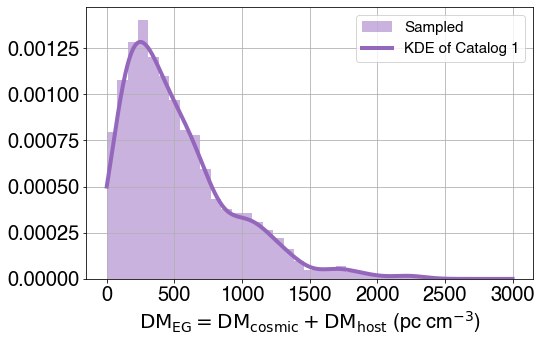

In [10]:
fig = plt.figure(figsize=(8,5))

bins = np.linspace(0,3000,40)
density=True
hist, bins, _ = plt.hist(rand_DMex, bins=bins, color=cycle[4], lw=4, alpha=0.5, density=density, label=f"Sampled")
#hist, bins, _ = plt.hist(DMex, bins=bins, color=cycle[0], lw=4, alpha=0.5, density=density, label=f"Catalog 1")
plt.plot(dms, DMex_kde, color=cycle[4], lw=4, label='KDE of Catalog 1')
plt.grid(zorder=1)
# plt.ylabel(r'$\rm N_{FRB}$')
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.legend(fontsize=15)


In [11]:
# Grab redshifts
zs = []
rand = np.random.uniform(size=NFRB)
for kk,DMc in enumerate(rand_DMex):
    imin = np.argmin(np.abs(dmvals-DMc))
    z = fs[imin](rand[kk])
    zs.append(float(z))
zs = np.array(zs)

In [14]:
# Get absolute magnitudes

fname = './Lz_host_data.csv' # From Alexa Gordon, complete up to Shannon+24
df = pandas.read_csv(fname)

# Scale mrs with z's to find distribution of Mrs
mrs = np.array(df['r-band'])
zs_mrs = np.array(df['redshift'])

# Get luminosity distance
ds = cosmo.luminosity_distance(zs_mrs).to(u.parsec).value

# Calculate absolute magnitudes
Mrs = mrs - 5. * np.log10(ds) + 5

# Remove those with z > 0.2
Mrs_cut = Mrs[zs_mrs <= 0.2]

# Load the previous distribution
Mr, density = hosts_mod.load_Mr_pdf()

# Calculate KDE of absolute magnitudes
kernel = stats.gaussian_kde(Mrs)#, bw_method=0.6)
mags = np.linspace(-25., -15., 500)
Mr_kde = kernel(mags)

kernel = stats.gaussian_kde(Mrs_cut)#, bw_method=0.6)
mags = np.linspace(-25., -15., 500)
Mr_kde_cut = kernel(mags)

In [15]:
# Now apparent magnitude
cum_Mr = np.cumsum(Mr_kde)
cum_Mr[0] = 0.
fMr = interp1d(cum_Mr/cum_Mr[-1], mags)
rand = np.random.uniform(size=NFRB)
rand_Mr = fMr(rand)

dist_mod = frb_cosmo.distmod(zs).value
host_m_r = dist_mod + rand_Mr

In [18]:
# Grab P(z,DM) grid to plot
grid = all_rates
z = zvals
DM_EG = dmvals
pzDM = grid.flatten()
cum_sum = np.cumsum(pzDM)
# Normalize
cum_sum = cum_sum/cum_sum[-1]

# Interpolate
DM, Z = np.meshgrid(DM_EG, z)  # 2D grid for interpolation
interp = CloughTocher2DInterpolator(list(zip(Z.ravel(), DM.ravel())), grid.ravel(), fill_value=np.nan)
# Make new regular grid of z, dm coordinates
z_new_list = np.linspace(0, 2.5, 500)
dm_new_list = np.linspace(0, 4000, 500)
z_new, dm_new = np.meshgrid(z_new_list, dm_new_list)
Pz_dm_interp = interp(z_new, dm_new)
Pz_dm_interp[Pz_dm_interp < 0.] = 0.

<ipython-input-19-31b1af0d1441>:29: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:


Text(0.5, 0, 'Redshift z')

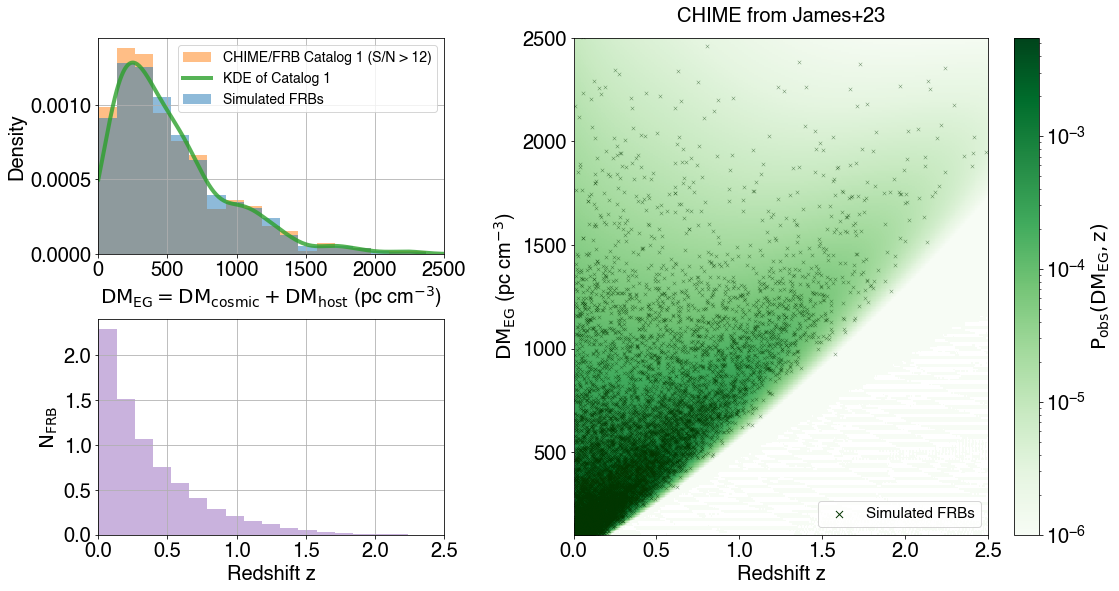

In [19]:
fig = plt.figure(figsize=(12, 6))

# (left, bottom, width, height)
height = 1/2.
sep_h = 0.15
width = 0.4
sep_w = 0.15
ax_z = (0., 0., width, height)
ax_dmeg = (0., (height+sep_h), width, height)
ax_pzdm = (width+sep_w, 0., 0.6, height*2+sep_h)

ax = plt.axes(ax_pzdm)
my_cmap = matplotlib.colormaps['Greens'] # copy the default cmap, cubehelix
# my_cmap.set_bad((0,0,0))
pc = ax.pcolormesh(
    z_new, dm_new, Pz_dm_interp, cmap=my_cmap, 
    norm=matplotlib.colors.LogNorm(vmin=1e-6), # vmin=1e-6, vmax=2e-4
    rasterized=True,
)
plt.colorbar(pc, label=r'$\rm P_{obs}(DM_{EG},z)$')
# plt.scatter(z_samp, DM_EG_samp, color='xkcd:lightish blue', alpha=.5, s=12, linewidth=0.5, edgecolor='xkcd:dark blue', rasterized=True)
plt.scatter(zs, rand_DMex, marker='x', color='xkcd:dark green', alpha=.5, s=12, linewidth=0.5, rasterized=True, label='Simulated FRBs')
plt.xlim([0, 2.5])
plt.ylim([100, 2500])
plt.xlabel('Redshift z')
plt.ylabel(r'$\rm DM_{EG}$ (pc cm$^{-3}$)')#' = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.title(r'CHIME from James+23', fontsize=20, y=1.02) #  $\rm P_{obs}(z|DM_{EG})$
leg = plt.legend(fontsize=15)
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    lh.set_sizes([50])
    lh.set_linewidth([1])
    
ax = plt.axes(ax_dmeg)
bins = np.linspace(0,2500,20)
density = True
hist = plt.hist(DMex, bins=bins, color=cycle[1], density=density, alpha=0.5, label='CHIME/FRB Catalog 1 (S/N > 12)')
plt.plot(dms, DMex_kde, color=cycle[2], alpha=0.8, lw=4, label='KDE of Catalog 1')#  / np.nanmax(DMex_kde)*np.nanmax(hist[0])
hist = plt.hist(rand_DMex, bins=bins, color=cycle[0], density=density, alpha=0.5, label='Simulated FRBs')
plt.xlim([0,2500])
plt.ylabel('Density')
plt.grid(zorder=1)
plt.legend(fontsize=14)
# _ = plt.yticks(np.arange(0, 1000+1, 500))
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')

ax = plt.axes(ax_z)
bins = np.linspace(0,2.5,20)
hist = plt.hist(zs, bins=bins, density=True, color=cycle[4], alpha=0.5)
plt.ylabel(r'$\rm N_{FRB}$')
plt.xlim([0,2.5])
plt.grid(zorder=1)
plt.xlabel(r'Redshift z')

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'frb_props_redo.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [20]:
combined_catalog_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'catalogs', 'combined_HSC_PS1_HECATE_galaxies.parquet')
combined_catalog = pandas.read_parquet(combined_catalog_fn)

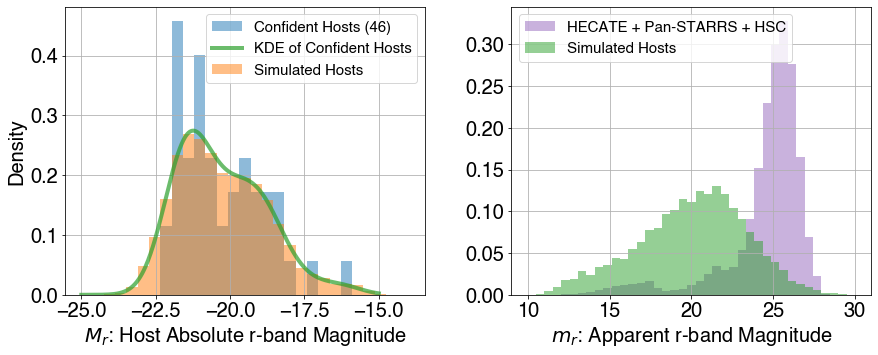

In [21]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
width = 0.5
sep_w = 0.12
Mr_ax = (0., 0., width, 1.)
mr_ax = (width+sep_w, 0., width, 1.)

fig = plt.figure(figsize=(10,4))

ax = plt.axes(Mr_ax)
bins = np.linspace(-25, -14, 30)
hist, bins, _ = plt.hist(Mrs, bins=bins, color=cycle[0], lw=4, alpha=0.5, density=True, label=f"Confident Hosts ({len(Mrs)})")
plt.plot(mags, Mr_kde, color=cycle[2], lw=4, label='KDE of Confident Hosts', alpha=0.7)
hist = plt.hist(rand_Mr, bins=bins, color=cycle[1], density=True, alpha=0.5, label='Simulated Hosts')
plt.xlabel('$M_r$: Host Absolute r-band Magnitude')
plt.ylabel('Density')
plt.legend(fontsize=15)
plt.grid(zorder=1)

ax = plt.axes(mr_ax)
bins = np.linspace(10, 30, 40)
inds = np.random.randint(low=0, high=len(combined_catalog), size=500000)
hist, bins, _ = plt.hist(combined_catalog.iloc[inds]['mag'], bins=bins, color=cycle[4], lw=4, alpha=0.5, density=True, label=f"HECATE + Pan-STARRS + HSC")
hist, bins, _ = plt.hist(host_m_r, bins=bins, color=cycle[2], lw=4, alpha=0.5, density=True, label=f"Simulated Hosts")
plt.grid(zorder=1)
# plt.ylabel(r'$\rm N_{FRB}$')
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.legend(fontsize=15, loc='upper left')
# plt.ylim([0,0.5])

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'Mr_distribution_redo.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [575]:
# Build FRB table
df_frbs = pandas.DataFrame()
df_frbs['DMex'] = rand_DMex
df_frbs['z'] = zs
df_frbs['M_r'] = rand_Mr
df_frbs['m_r'] = host_m_r
df_frbs.to_parquet('./generated_frbs_fix.parquet')